# Accessing Gridded Climate Data <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` & `NCI` environments
* **Products used:** 
[ERA5](https://registry.opendata.aws/ecmwf-era5/) and [ANUClim](https://fennerschool.anu.edu.au/research/products/anuclim-version-6-1) (*these datasets are external to the Digital Earth Australia platform*)

## Background & Description

This notebook demonstrates how to access and use **Australian-specific climate data** stored on the National Computing Infrastructure (NCI), and **global climate reanalysis data (ERA5)** hosted on Google's cloud infrastructure. The content is structured into two parts.

1. The first section shows how to access an Australian climate dataset through the THREDDS platform. [NCI's THREDDS](https://thredds.nci.org.au/thredds/catalog/catalog.html) provides a wide range of climate, satellite, and other gridded environmental datasets, which can be accessed programmatically via `xarray`. 
2. The second section focuses on the use of a pre-processed version of the  [ECMWF Reanalysis v5 (ERA5) Climate Fields](https://github.com/google-research/arco-era5). These datasets are also accessed using `xarray`.

> Note: Additional details about the datasets are provided further in the notebook.

## Analysis parameters

The following code cell is used to define variable needed later.

* `vector_path`: a file path to the polygon that defines our analysis region, the default example uses a boundary of Victoria.
* `year`: the year of data you want to load, use string value only.

In [1]:
# Boundary of victoria
vector_path = '../Supplementary_data/External_data_Climate/victoria_boundary.geojson'

# Define the year of interest
year = '2020' 

## Load packages

Import Python packages that are used for the analysis.

In [2]:
%matplotlib inline

import os
import gcsfs
import requests
import datacube
import xarray as xr
import pandas as pd
import numpy as np
import contextily as ctx
import geopandas as gpd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from odc.geo.xr import assign_crs
from odc.geo.geom import Geometry, BoundingBox 

from datacube.utils.dask import start_local_dask

## Open a dask client

In [3]:
client = start_local_dask()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/8787/status,
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 2,Total memory: 14.51 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44265,Workers: 1
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 14.51 GiB
Comm: tcp://127.0.0.1:41631,Total threads: 2
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/44267/status,Memory: 14.51 GiB
Nanny: tcp://127.0.0.1:42755,


## Section 1: ANUClim climate data

In the first section of this notebook, we demonstrates retrieval of the **Australian National University's Climate data product ('ANUClim')**. These datasets are produced using topographically conditional spatial interpolation of Australia's extensive network of weather stations.

The available variables include:
* `tavg`: Average surface air temperature
* `rain`: Total precipitation
* `vpd` : Vapour pressure deficit
* `srad`: Incoming solar radiation
* `evap`: Pan evaporation

The entire archive can be viewed [here](https://thredds.nci.org.au/thredds/catalog/gh70/ANUClimate/v2-0/stable/catalog.html)

Data is available at a `daily` and `monthly` cadence, and has a 1 x 1 km spatial resolution, making it one of the highest resolution climate data products available for Australia. The time range of the data depends on the climate variable. For example, rainfall goes back to 1900, while air temperature begins in 1960. Data is updated annually.

> Note: ANUClim is stored in the `'EPSG:4283'` projection

***

### Analysis parameters for ANUClim

* `var`: the climate variable to load.
* `cadence`: specifies whether to load monthly or daily data. Must be either 'month' or 'day'.

In [4]:
# Which variable should we load?
var = 'rain' # other options: vpd, srad, rain, evap,  tavg

# Define the cadence of the data to load 
cadence= 'month' # other options: day

### Load our region of interest

In [5]:
# open the vector file
gdf = gpd.read_file(vector_path)

# convert to GDA94 to match ANUClim's CRS
gdf = gdf.to_crs('epsg:4283')

# define bounding box of the geometry
# we'll use this to select data before masking
bb = gdf.total_bounds

### Load the climate data through THREDDS
Extract the links for loading the target year data from THREDDS using `xarray`.

In [6]:
# the following the top level folder on the NCI
thredds_data_link = 'https://thredds.nci.org.au/thredds/dodsC/gh70/ANUClimate/v2-0/stable/'
thredds_catalog_link=f'https://thredds.nci.org.au/thredds/catalog/gh70/ANUClimate/v2-0/stable/{cadence}/'

# get list of all the file links on the THREDDS server
ff = f'{thredds_catalog_link}{var}/{year}/catalog.html'
soup = BeautifulSoup(requests.get(ff).content, "html.parser")

# extract just the href links
file_names = [] 
for link in soup.select('a[href*=".html"]'): # loop over all <a> elements where the href attribute contains ".html"
    href = link["href"]
    if "dataset" in href: # add only file names of datasets to list
        file_names.append(href)

# create a list of links for xarray
list_of_links = [thredds_data_link+f.replace('catalog.html?dataset=gh70/', '') for f in file_names]

# open with xarray and tidy up
ds = xr.open_mfdataset(list_of_links)
ds = assign_crs(ds, crs='epsg:4283') #GDA94
ds = ds.drop_vars('crs')[var]
ds.attrs['nodata'] = np.nan

# select data from within the bounding box of the geometry
# this is faster than masking, which we can do later
climate = ds.sel(lat=slice(bb[3], bb[1]), lon=slice(bb[0],bb[2]))
climate.load() #bring into memory

# mask out all pixels outside of our ROI
# convert to a Geometry object for masking
geometry = gdf.iloc[0].geometry
geom = Geometry(geom=geometry, crs=gdf.crs) # use same CRS of the vector file
climate = climate.odc.mask(poly=geom)

### Plot annual data

Below we resample the climate data into an annual series. As we have loaded rainfall in the default example, we calculate an annual sum. This statistic may not make sense if you are loading a different variable. 

In [7]:
climate_annual = climate.resample(time='1YE').sum()
climate_annual = climate_annual.odc.mask(poly=geom) # need to remask after a sum to remove zeros

/env/lib/python3.10/site-packages/odc/geo/_xr_interop.py:500: UserWarning: grid_mapping=crs is not pointing to valid coordinate
  warnings.warn(


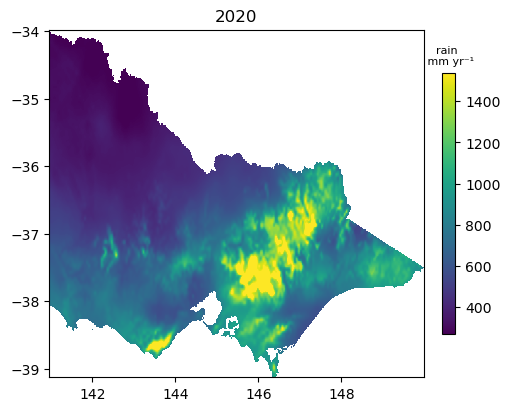

In [8]:
fig, ax = plt.subplots(figsize=(5, 4), layout='constrained')

im = climate_annual.isel(time=0).plot(cmap='viridis', add_labels=False, robust=True, add_colorbar=False, ax=ax)
ax.set_title(climate_annual.isel(time=0).time.dt.year.item())

cb = fig.colorbar(im, ax=ax, shrink=0.75, orientation='vertical')
cb.ax.set_title(var + ' \n mm yr\u207B\u00B9', fontsize=8);

## Section 2: ECMWF Reanalysis v5 (ERA5)

We can also load ERA5 reanalysis datasets using Google's collection of Analysis-Ready, Cloud Optimized ERA5 data.  ERA5 has a coarse spatial resolution (~25 km) compared with ANUClim, but provides hourly reconstructions of past climate and has many more climate fields at both surface and pressure levels.

A list of variables to load is available in the [data summary table](https://github.com/google-research/arco-era5/tree/main?tab=readme-ov-file#025-pressure-and-surface-level-data). Some commonly used long and short variable names are the following:
* `2 metre temperature` : `2t`
* `total_precipitation` : `tp`
* `2m_dewpoint_temperature` : `2d`
* `evaporation` : `e`
* `10m_u_component_of_wind` : `10u`
* `10m_v_component_of_wind` : `10v`
* `Surface short-wave (solar) radiation downwards` : `ssrd`

**Provide a variable name in the cell below**

In [9]:
era5_var = 'total_precipitation'

### Define a function for loading ERA5

In [10]:
def load_era5(
    x=None,
    y=None,
    crs="EPSG:4326",
    time=None,
    bands=None,
    chunks=None,
    path="gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3",
):
    # Lazily load Zarr from Google Cloud Platform
    era5_ds = xr.open_zarr(path, chunks=chunks, storage_options=dict(token="anon"))

    # Select bands
    era5_ds = era5_ds[bands] if bands is not None else era5_ds

    # Clip to extent
    if x is not None:
        bbox = BoundingBox.from_xy(x, y, crs=crs).to_crs(crs)
        era5_ds = era5_ds.sel(
            longitude=slice(bbox.left, bbox.right),
            latitude=slice(bbox.top, bbox.bottom),
        )
        
    # Select time
    if time is not None:
        if len(time)>1:
            era5_ds = era5_ds.sel(time=slice(time[0], time[-1]))
        else: # if only single year
            era5_ds = era5_ds.sel(time=slice(f'{year}-01-01', f'{year}-12-31'))

    return era5_ds.odc.assign_crs(crs)


### Convert the polygon back to EPSG:4326

In [11]:
# convert our vector back to EPSG 4326 for ERA5
gdf = gdf.to_crs('epsg:4326')

# define bounding box of the geometry
# we'll use this to select data before masking
bb = gdf.total_bounds

### Load total precipitation

In [12]:
era5_climate = load_era5(
    x=(bb[0],bb[2]),
    y=(bb[1],bb[3]),
    crs="EPSG:4326",
    time=[year],
    bands=[era5_var],
    chunks=dict(time=2924), #hours in two years divided by six
    path="gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3",
)

era5_climate = era5_climate[era5_var]
era5_climate

<xarray.DataArray 'total_precipitation' (time: 8784, latitude: 21, longitude: 36)> Size: 27MB
dask.array<getitem, shape=(8784, 21, 36), dtype=float32, chunksize=(2924, 21, 36), chunktype=numpy.ndarray>
Coordinates:
  * latitude     (latitude) float32 84B -34.0 -34.25 -34.5 ... -38.75 -39.0
  * longitude    (longitude) float32 144B 141.0 141.2 141.5 ... 149.5 149.8
  * time         (time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23:00:00
    spatial_ref  int32 4B 4326
Attributes:
    long_name:   Total precipitation
    short_name:  tp
    units:       m

### Resample to annual

As ERA5 has an hourly time step, we need to use dask to resample into annual time fields as there is a lot of data even though the spatial extent of the subset of data is small. This can be quite slow, ~4 mins on the default sandbox.

In [13]:
era5_climate_annual = era5_climate.resample(time='1YE').sum().load()

### Mask with the polygon

In [14]:
geometry = gdf.iloc[0].geometry
geom = Geometry(geom=geometry, crs=gdf.crs)
era5_climate_annual = era5_climate_annual.odc.mask(poly=geom) # need to remask after a sum to remove zeros

### Plot an annual summary data

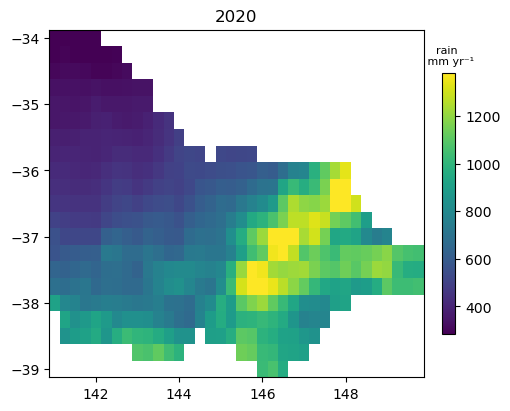

In [15]:
fig, ax = plt.subplots(figsize=(5, 4), layout='constrained')

im = (era5_climate_annual*1000).isel(time=0).plot(cmap='viridis', add_labels=False, robust=True, add_colorbar=False, ax=ax);  # multiply by 1000 to convert into mm
ax.set_title(era5_climate_annual.isel(time=0).time.dt.year.item())

cb = fig.colorbar(im, ax=ax, shrink=0.75, orientation='vertical')
cb.ax.set_title(var + ' \n mm yr\u207B\u00B9', fontsize=8);

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** April 2025

**Compatible datacube version:** 

In [16]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->